- The Algorithm keeps a counter `Z` for every unique (X,Y) pair
- The counter is then converted into a dataframe with the values being sorted in ascending order
- The dataframe is then plotted to get the required V-Plot

Total number of Unique (X, Y) pairs present in the input file: 280653


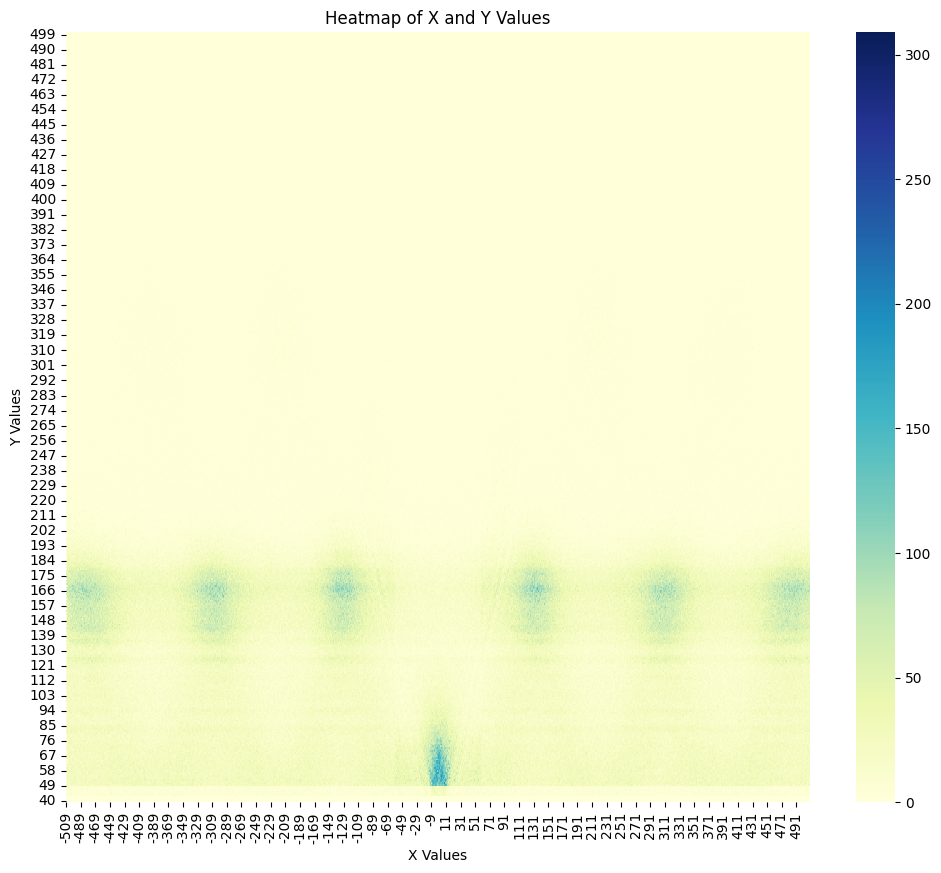

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

Z = Counter()

# Read and parse each line to compute X and Y
with open('mapped.bed', 'r') as df:
    for line in df:
        parts = line.strip().split('\t')
        C1 = (int(parts[2]) + int(parts[3])) / 2
        C2 = (int(parts[8]) + int(parts[9])) / 2
        X = int(C2 - C1)
        Y = int(int(parts[9]) - int(parts[8]))
        
        Z[(X, Y)] += 1

print("Total number of Unique (X, Y) pairs present in the input file:", len(Z))

# Creating sorted lists to store Unique X and Y Values
X_values = sorted(set(x for x, y in Z.keys()))
Y_values = sorted(set(y for x, y in Z.keys()))

Count_Matrix = np.zeros((len(Y_values), len(X_values)), dtype=int)
for i, y in enumerate(Y_values):
    for j, x in enumerate(X_values):
        Count_Matrix[i, j] = Z.get((x, y), 0)

# Creating a DataFrame from the Count Matrix
Count_Matrix_df = pd.DataFrame(Count_Matrix, index=Y_values, columns=X_values)

# Plotting the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(Count_Matrix_df, cmap='YlGnBu', annot=False, fmt='d')
plt.gca().invert_yaxis()
plt.title('Heatmap of X and Y Values')
plt.xlabel('X Values')
plt.ylabel('Y Values')
plt.show()